# B: Analisis Kualitas Layanan & Pain Points

## Identitas

**Nama :**

**NIM :**

**Program Studi :** Teknologi Informasi

**GitHub Repository :** [Telecom-Churn-Rate_Kelompok-2](https://github.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2)

**Dataset :** Telecom Customer Churn Feature Engineering Dataset (hasil preprocessing Notebook D — `telecome_clean.csv`)

**Peran dalam Kelompok :** Orang B — Analisis Kualitas Layanan (*Service Quality*) dan Titik Kritis Pelanggan (*Pain Points*)

---
# 0. Ringkasan Revisi (Dibaca Dulu Sebelum Lanjut)

Sebelum masuk ke analisis inti, aku mau cerita dulu secara ringkas apa saja yang berubah dari draf lama (`B_service_dan_painPoints.ipynb`) ke draf revisi ini. Tujuannya sederhana: supaya dosen tidak perlu membandingkan file lama dan file baru baris demi baris untuk tahu bagian mana yang sudah diperbaiki.

Ada empat catatan utama dari dosen, dan berikut bagaimana masing-masing aku tindaklanjuti:

| No | Masukan Dosen | Masalah di Draf Lama | Perbaikan di Draf Ini |
|---|---|---|---|
| 1 | Fokus hanya ke pelanggan yang churn, bukan seluruh data | Statistik deskriptif, distribusi, dan pivot table semuanya dihitung dari 1.200 baris (seluruh pelanggan) | Dibuat subset `df_churn` berisi 420 baris (35% dari total) di Bagian 5.4. Mulai Bagian 6 sampai 10, seluruh profil dan distribusi memakai `df_churn`, bukan `df` penuh |
| 2 | Ganti histogram jadi scatter plot churn vs tidak churn | Kualitas layanan dilihat lewat histogram/boxplot satu variabel yang dipisah per kelompok | Bagian 8 sekarang pakai scatter plot dua variabel numerik sekaligus, dengan warna dibedakan berdasarkan `churn_status`, supaya pola *interaksi* dua variabel kelihatan, bukan cuma sebaran satu variabel |
| 3 | Rekomendasi harus berbasis data feedback | Rekomendasi sebelumnya lebih terasa seperti opini umum | Bagian 13 dibuka dengan tabel kuantifikasi kategori feedback, dan setiap poin rekomendasi sekarang mencantumkan angka pendukungnya secara eksplisit |
| 4 | Rapikan struktur dan grafik | Notebook lama langsung masuk ke eksplorasi tanpa peta analisis, dan minim penjelasan sebelum/sesudah grafik | Ditambahkan Bagian 1 (Pendahuluan & Peta Analisis) di awal, penjelasan "kenapa" sebelum tiap bagian, dan interpretasi hasil sesudah tiap grafik/tabel — mengikuti pola struktur yang sama dengan Notebook D |

Di luar empat poin itu, ada satu hal yang aku tambahkan sendiri karena menurutku penting untuk menjaga konsistensi logika: aku pisahkan dengan tegas bagian mana yang **masih boleh** memakai seluruh data (karena tujuannya membandingkan dua kelompok) dan bagian mana yang **wajib** hanya memakai data churn (karena tujuannya memotret populasi churn itu sendiri). Penjelasan lengkapnya ada di Bagian 1.2.

> 💡 **Cara membaca catatan revisi di notebook ini:** di beberapa bagian yang paling signifikan berubah, aku selipkan kotak catatan kecil seperti ini yang menandai secara spesifik apa yang diganti dari draf lama. Jadi kalau dosen ingin cek cepat, tinggal cari kotak-kotak bertanda 📝 di sepanjang notebook.


---
# 1. Pendahuluan & Peta Analisis

Sebelum mulai eksplorasi, aku pikir penting untuk berhenti sejenak dan menjelaskan dulu mau ke mana arah notebook ini — supaya orang yang membaca (termasuk dosen) tidak perlu menebak-nebak logika di baliknya sambil menelusuri kode satu per satu.

## 1.1 Rumusan Masalah yang Dijawab

Notebook ini secara khusus menjawab rumusan masalah kedua dari proyek kelompok kami:

> **Bagaimana kualitas layanan dan *pain points* pelanggan berkontribusi terhadap keputusan *churn*?**

dengan tujuan **menganalisis hubungan kualitas layanan dan *pain points* pelanggan terhadap *churn***. Jadi, semua langkah di bawah — mulai dari statistik deskriptif sampai rekomendasi — pada akhirnya harus mengarah untuk menjawab pertanyaan itu, bukan sekadar eksplorasi data secara umum.

## 1.2 Posisi Notebook B terhadap General EDA (Notebook D)

Ini bagian yang menurutku penting untuk diluruskan, karena sempat jadi sumber kesalahan di draf lama. Notebook D (`D_master.ipynb`) sudah melakukan **General EDA**: memeriksa proporsi target `churn`, melihat hubungan awal seluruh variabel terhadap `churn` secara sekilas, dan mengecek multikolinearitas lewat matriks korelasi penuh. Tujuannya di sana adalah memastikan dataset **siap dipakai untuk pemodelan**.

Nah, Notebook B ini **tidak mengulang** pekerjaan itu. Sebagai **Specific EDA**, notebook ini punya dua pekerjaan yang sifatnya berbeda dari General EDA, dan perbedaan ini yang jadi kunci kenapa aku memisahkan penggunaan data di beberapa bagian:

1. **Pekerjaan konfirmatif** — memastikan dengan cara yang lebih tajam (bukan sekadar bar chart rata-rata) bahwa variabel kualitas layanan (`support_tickets`, `contract_type`, `city`) memang berasosiasi dengan `churn`. Karena tujuannya membandingkan dua kelompok, bagian ini **masih memakai seluruh baris data**.
2. **Pekerjaan diagnostik (inti tugas Orang B)** — begitu asosiasi itu terkonfirmasi, pertanyaan berikutnya adalah: **dari pelanggan yang benar-benar churn, seperti apa profil pain point mereka?** Ini pertanyaan tentang populasi churn itu sendiri, bukan lagi soal membandingkan churn vs tidak churn, sehingga bagian ini **hanya memakai subset pelanggan dengan `churn = 1`**.

Pemisahan dua pekerjaan inilah yang menjadi revisi paling mendasar dari draf sebelumnya, yang dulu memakai seluruh data (1.200 baris) untuk seluruh analisis Bagian B — termasuk bagian yang seharusnya jadi profil murni populasi churn.

> 📝 **Catatan revisi:** seluruh Bagian 1 ini baru ditambahkan di draf revisi. Sebelumnya notebook langsung mulai dari import library tanpa ada peta analisis di depan.

## 1.3 Variabel yang Digunakan dan Alasannya

| Variabel | Peran | Alasan Pemilihan |
|---|---|---|
| `support_tickets_capped` | Indikator keluhan operasional | Proksi langsung frekuensi masalah yang dialami pelanggan |
| `contract_type_encoded` / `contract_type_label` | Bentuk komitmen pelanggan | Mencerminkan *barrier to exit* — kontrak pendek = mudah churn |
| `city_name` (hasil rekonstruksi one-hot) | Lokasi geografis | Mendeteksi pain point yang bersifat regional/infrastruktur |
| `feedback_category` | Kategori sentimen umpan balik | Ringkasan kualitatif keluhan pelanggan dalam bentuk terukur |
| `count_support`, `count_helpful`, `count_poor`, `count_expensive`, `count_unreliable`, `count_drops`, `count_slow` | Kata kunci spesifik dari `customer_feedback` | Dasar kuantitatif untuk menyusun rekomendasi berbasis isi keluhan (bukan tebakan) |
| `tenure_months`, `monthly_bill_capped` | Variabel pendukung | Dipakai pada analisis interaksi (scatter plot) untuk melihat pola gabungan, bukan sebagai fokus utama Bagian B |
| `churn_status` (hasil rename dari `churn`) | Variabel target | Dasar pembagian populasi churn vs tidak churn |

## 1.4 Alur Analisis (Roadmap)

Supaya lebih gampang diikuti, berikut urutan logika yang aku pakai dari awal sampai akhir notebook ini:

1. Persiapan data (rename, labeling, rekonstruksi kota, **pembentukan subset churn**)
2. Statistik deskriptif profil pelanggan churn
3. Distribusi variabel kunci **pada populasi churn**
4. Analisis komparatif churn vs tidak churn dengan **scatter plot interaksi** (bagian konfirmatif)
5. Analisis multivariat (pivot table) pada populasi churn
6. Validasi outlier
7. Korelasi antar variabel kualitas layanan
8. Insight bisnis
9. **Rekomendasi berbasis data feedback pelanggan**
10. Kesimpulan


---
# 2. Import Library

Langkah pertama seperti biasa: menyiapkan pustaka yang dibutuhkan. Aku sengaja memakai pustaka yang sama dengan Notebook D — `pandas` dan `numpy` untuk manipulasi data, `matplotlib` dan `seaborn` untuk visualisasi — supaya gaya kode dan tampilan grafik di kedua notebook konsisten satu sama lain.


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

### Interpretasi

Seluruh pustaka berhasil dimuat, dan gaya visual (`whitegrid`) sudah diterapkan di awal. Ini kelihatannya langkah kecil, tapi manfaatnya baru terasa nanti: seluruh grafik di notebook ini jadi punya tampilan yang konsisten tanpa perlu diatur ulang di setiap sel.


---
# 3. Memuat Dataset Bersih

Dataset yang dimuat di sini adalah `telecom_clean.csv`, yaitu keluaran akhir dari tahap *Data Preprocessing* dan *General EDA* pada Notebook D. Kenapa aku tidak memuat data mentah lagi dari awal? Karena dataset ini sudah bebas dari *missing value* dan duplikat, dan sudah melalui *capping outlier*, *encoding*, serta ekstraksi fitur teks dari `customer_feedback`. Jadi Notebook B ini bisa langsung fokus ke analisis, tidak perlu mengulang pembersihan data dari nol.


In [3]:
url = "https://raw.githubusercontent.com/AIU7AgrataEleigh/Telecom-Churn-Rate_Kelompok-2/refs/heads/main/data/telecome_clean.csv"

df = pd.read_csv(url)
df.head()

,gender,churn,monthly_bill_capped,internet_usage_gb_capped,call_minutes_capped,support_tickets_capped,tenure_months,financial_risk,education_level_encoded,contract_type_encoded,...,city_Gujranwala,city_Hyderabad,city_Islamabad,city_Karachi,city_Lahore,city_Multan,city_Peshawar,city_Quetta,city_Rawalpindi,city_Sialkot
0,1,0,10049.0,5.8,52.0,1,91,0,2,1,...,0,0,0,0,0,1,0,0,0,0
1,0,0,2752.0,11.9,22.0,2,91,0,3,1,...,0,0,0,0,0,0,1,0,0,0
2,1,0,3155.0,40.0,87.0,0,91,0,1,0,...,1,0,0,0,0,0,0,0,0,0
3,1,0,5859.0,8.5,147.0,2,90,0,1,1,...,0,0,0,0,1,0,0,0,0,0
4,0,0,5106.0,3.3,183.0,0,90,0,0,2,...,0,1,0,0,0,0,0,0,0,0


### Interpretasi

Dataset berhasil dimuat. Kolom-kolom yang tampil di `head()` sudah mengonfirmasi bahwa data ini benar dalam bentuk numerik hasil *encoding* (misalnya `monthly_bill_capped`, `support_tickets_capped`, `contract_type_encoded`, dan kolom *one-hot* `city_*`) — persis sesuai hasil akhir Notebook D. Artinya, aku bisa lanjut dengan yakin bahwa data yang dipakai memang sudah bersih.


---
# 4. Validasi Awal Dataset

Sebelum masuk lebih jauh, aku selalu membiasakan diri untuk melakukan validasi cepat dulu — bukan karena tidak percaya pada Notebook D, tapi lebih ke kebiasaan baik: memastikan tidak ada perubahan struktur data yang tidak disengaja sejak diekspor. Validasi ini mencakup ukuran dataset, tipe data, dan pengecekan nilai kosong.


In [4]:
print("Bentuk dataset (baris, kolom):", df.shape)
print("\nJumlah missing value per kolom (total):", df.isna().sum().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())
df.info()

Bentuk dataset (baris, kolom): (1200, 42)

Jumlah missing value per kolom (total): 0

Jumlah baris duplikat: 0
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gender                        1200 non-null   int64  
 1   churn                         1200 non-null   int64  
 2   monthly_bill_capped           1200 non-null   float64
 3   internet_usage_gb_capped      1200 non-null   float64
 4   call_minutes_capped           1200 non-null   float64
 5   support_tickets_capped        1200 non-null   int64  
 6   tenure_months                 1200 non-null   int64  
 7   financial_risk                1200 non-null   int64  
 8   education_level_encoded       1200 non-null   int64  
 9   contract_type_encoded         1200 non-null   int64  
 10  emp_Employed                  1200 non-null   bool   
 11  emp_Retired          

### Interpretasi

Dataset berisi **1.200 baris dan 42 kolom**, tanpa nilai kosong maupun baris duplikat. Seluruh kolom juga sudah bertipe numerik (`int64`, `float64`, atau `bool`). Dengan kata lain, data ini konsisten dengan hasil akhir Notebook D dan aman untuk dianalisis lebih lanjut — tidak ada kejutan yang perlu dikhawatirkan di titik ini.


---
# 5. Persiapan Data Analisis

Sebelum masuk ke statistik dan visualisasi, ada beberapa hal yang perlu dirapikan dulu supaya kolom-kolom lebih gampang dibaca dan diinterpretasikan. Dan yang paling penting — ini juga jadi tempat aku melakukan **perbaikan utama** dari draf sebelumnya: membentuk subset khusus pelanggan yang benar-benar churn.

## 5.1 Rename Kolom Target

Langkah pertama, kolom `churn` aku ganti namanya menjadi `churn_status`. Alasannya sederhana: supaya tidak rancu antara "churn" sebagai konsep/istilah bisnis dengan "churn" sebagai nama kolom, dan supaya penamaan variabel konsisten dipakai di seluruh notebook ini.


In [5]:
df = df.rename(columns={'churn': 'churn_status'})
print("Kolom 'churn' berhasil diganti nama menjadi 'churn_status'.")

Kolom 'churn' berhasil diganti nama menjadi 'churn_status'.


### Interpretasi

Kolom target sekarang bernama `churn_status`, jadi setiap kali dipakai di `groupby`, `pivot_table`, atau visualisasi, penyebutannya jadi lebih eksplisit dan tidak membingungkan.

## 5.2 Pembuatan Label Jenis Kontrak

Kolom `contract_type_encoded` berisi nilai numerik hasil *ordinal encoding* dari Notebook D (0 = Monthly, 1 = 6-Month, 2 = 12-Month). Daripada mengingat-ingat angka ini di setiap grafik, aku buat label teksnya sekali saja di awal — supaya tidak perlu diulang-ulang di setiap sel kode seperti yang terjadi di draf sebelumnya.


In [6]:
contract_mapping = {0: 'Monthly', 1: '6 Month', 2: '12 Month'}
df['contract_type_label'] = df['contract_type_encoded'].map(contract_mapping)

contract_order = ['Monthly', '6 Month', '12 Month']

df[['contract_type_encoded', 'contract_type_label']].drop_duplicates().sort_values('contract_type_encoded')

,contract_type_encoded,contract_type_label
2,0,Monthly
0,1,6 Month
4,2,12 Month


### Interpretasi

Kolom `contract_type_label` berhasil dibuat dan konsisten dengan pemetaan pada Notebook D. Aku juga menyiapkan `contract_order` di sini sekali untuk seluruh notebook, supaya urutan kategori pada semua grafik nanti konsisten (Monthly → 6 Month → 12 Month), bukannya acak tiap kali dibuat grafik baru.

## 5.3 Rekonstruksi Nama Kota

Kolom kota di dataset ini tersimpan dalam format *one-hot encoding* (`city_Faisalabad`, `city_Lahore`, dan seterusnya). Supaya analisis geografis lebih mudah dibaca, aku rekonstruksi jadi satu kolom `city_name` memakai `idxmax()`.


In [7]:
city_columns = [col for col in df.columns if col.startswith('city_')]
df['city_name'] = df[city_columns].idxmax(axis=1).str.replace('city_', '')

df[['city_name']].value_counts()

city_name 
Quetta        119
Rawalpindi    116
Gujranwala    115
Multan        113
Sialkot       113
Peshawar      108
Lahore        108
Hyderabad     107
Faisalabad    103
Karachi       100
Islamabad      98
Name: count, dtype: int64

### Interpretasi

Kolom `city_name` berhasil direkonstruksi dan mencakup 11 kota, konsisten dengan deskripsi dataset pada laporan (Quetta, Rawalpindi, Gujranwala, Sialkot, Multan, Peshawar, Lahore, Hyderabad, Faisalabad, Karachi, Islamabad).

## 5.4 Membentuk Subset Data Pelanggan Churn

Nah, ini bagian yang paling krusial di seluruh notebook ini. **Ini adalah perbaikan utama** berdasarkan catatan dosen. Tugas Orang B adalah memahami *pain points* pelanggan yang **benar-benar meninggalkan layanan** — bukan menggambarkan kualitas layanan untuk seluruh pelanggan, karena itu sudah jadi bagian dari General EDA di Notebook D. Kalau aku tetap memakai seluruh data di bagian profil, hasilnya jadi bias: rata-rata dan distribusi yang muncul akan tercampur antara pelanggan yang puas dan yang tidak, padahal yang ingin dijawab justru "seperti apa pelanggan yang sampai memutuskan pergi".

Karena itu, subset `df_churn` dibentuk di sini, dan mulai bagian ini seterusnya akan jadi basis utama untuk statistik deskriptif, distribusi, dan analisis multivariat pada notebook ini.

Satu pengecualian yang tetap aku pertahankan: perbandingan terhadap populasi lengkap tetap dipakai **khusus** pada bagian yang secara eksplisit bertujuan menguji asosiasi churn vs tidak churn (Bagian 8), karena perbandingan semacam itu, secara definisi, memang membutuhkan kedua kelompok hadir bersamaan.

> 📝 **Catatan revisi:** subset `df_churn` ini sama sekali tidak ada di draf lama. Sebelumnya seluruh analisis Bagian B (Bagian 6 sampai 10 pada draf ini) dijalankan di atas 1.200 baris data penuh, padahal seharusnya hanya memakai 420 baris pelanggan churn.


In [8]:
df_churn = df[df['churn_status'] == 1].copy()

n_total = len(df)
n_churn = len(df_churn)

print(f"Jumlah total pelanggan  : {n_total}")
print(f"Jumlah pelanggan churn  : {n_churn}")
print(f"Proporsi churn          : {n_churn / n_total:.1%}")

Jumlah total pelanggan  : 1200
Jumlah pelanggan churn  : 420
Proporsi churn          : 35.0%


### Interpretasi

Subset `df_churn` berisi **420 pelanggan (35% dari total 1.200 pelanggan)**, sesuai dengan proporsi kelas target yang sudah dikonfirmasi pada General EDA Notebook D. Angka ini penting untuk dipegang, karena mulai bagian ini dan seterusnya, seluruh analisis profil dan distribusi akan memakai `df_churn`, kecuali dinyatakan lain secara eksplisit.


---
# 6. Statistik Deskriptif Profil Pelanggan Churn

Setelah subset churn siap, langkah paling wajar berikutnya adalah bertanya: "seperti apa sih, secara umum, profil pelanggan yang churn itu?" Statistik deskriptif di sini dihitung khusus pada `df_churn` untuk tiga variabel numerik kunci Bagian B: `support_tickets_capped`, `contract_type_encoded`, dan `monthly_bill_capped`. Ukuran pemusatan (mean, median, modus) membantu memahami profil "tipikal" pelanggan yang churn sebelum masuk ke visualisasi yang lebih detail.

**Catatan metodologis — kenapa `feedback_category` tidak ikut dihitung mean/median-nya di sini:** kolom ini berisi kode 0-3 (Biaya/Tagihan, Jaringan/Sinyal, Customer Support, Positif/Puas) yang sifatnya **nominal**, bukan skala berjenjang. Kalau tetap dihitung mean atau median-nya, hasilnya memang valid secara matematis, tapi **tidak bermakna** — mean 1,4 misalnya bukan berarti "rata-rata keluhan ada di antara Jaringan dan Support", karena urutan angkanya cuma label, bukan tingkatan. Modus tetap valid untuk data nominal sehingga tetap dihitung di sini, sementara distribusi lengkapnya (persentase tiap kategori) dibahas terpisah di Bagian 7.4 dengan visualisasi yang memang sesuai untuk data kategorikal.


In [9]:
key_vars = ['support_tickets_capped', 'contract_type_encoded', 'monthly_bill_capped']

print("Statistik Deskriptif Variabel Numerik Kunci (khusus populasi churn):")
display(df_churn[key_vars].describe())

profil = pd.DataFrame({
    'Mean': df_churn[key_vars].mean(),
    'Median': df_churn[key_vars].median(),
    'Modus': df_churn[key_vars].mode().iloc[0]
}).round(2)

display(profil)

# feedback_category nominal -> hanya modus yang bermakna, mean/median sengaja tidak dihitung
modus_feedback = df_churn['feedback_category'].mode().iloc[0]
feedback_label_map_preview = {0: 'Biaya/Tagihan', 1: 'Jaringan/Sinyal', 2: 'Customer Support', 3: 'Positif/Puas'}
print(f"\nModus feedback_category (populasi churn): {modus_feedback} -> {feedback_label_map_preview[modus_feedback]}")
print("(Mean/median sengaja tidak ditampilkan karena feedback_category bersifat nominal)")

Statistik Deskriptif Variabel Numerik Kunci (khusus populasi churn):


,support_tickets_capped,contract_type_encoded,monthly_bill_capped
count,420.000000,420.000000,420.000000
mean,2.114286,0.440476,6524.313690
std,1.052913,0.733631,3601.822682
min,0.000000,0.000000,1116.000000
25%,1.000000,0.000000,3651.500000
50%,2.000000,0.000000,5616.500000
75%,3.000000,1.000000,8676.250000
max,5.000000,2.000000,13776.125000


,Mean,Median,Modus
support_tickets_capped,2.11,2.0,2.00
contract_type_encoded,0.44,0.0,0.00
monthly_bill_capped,6524.31,5616.5,13776.12



Modus feedback_category (populasi churn): 1 -> Jaringan/Sinyal
(Mean/median sengaja tidak ditampilkan karena feedback_category bersifat nominal)


### Interpretasi

Rata-rata jumlah `support_tickets` pada populasi churn adalah **sekitar 2,1 tiket**, jauh di atas modus keseluruhan dataset (1 tiket pada Notebook D). Ini sudah menjadi sinyal awal bahwa pelanggan yang churn tipikalnya adalah pelanggan dengan keluhan berulang, bukan kejadian sekali-sekali. Modus `contract_type_encoded = 0` (Monthly) menunjukkan kontrak bulanan adalah kontrak paling umum di antara pelanggan yang churn. Modus `feedback_category` berada pada kategori **Jaringan/Sinyal**, sejalan dengan temuan distribusi lengkap yang akan dibahas di Bagian 7.4.

Satu hal yang perlu digarisbawahi: angka-angka ini **belum dibandingkan langsung** dengan kelompok tidak-churn di sini, karena tujuan bagian ini murni memotret profil populasi churn itu sendiri, bukan menguji perbedaan antar kelompok. Perbandingan formal itu baru dilakukan di Bagian 8.


---
# 7. Distribusi Variabel Kunci pada Populasi Churn

Kalau Bagian 6 tadi baru memberi angka ringkasan, bagian ini melangkah lebih jauh dengan memvisualisasikan sebaran empat variabel kualitas layanan **khusus pada pelanggan yang churn** (`df_churn`). Pertanyaannya: dari pelanggan yang sudah pergi, seperti apa pola keluhan, jenis kontrak, sebaran kota, dan kategori umpan balik mereka? Empat sub-bagian di bawah ini menjawabnya satu per satu.

## 7.1 Distribusi Jumlah Support Tickets

> 📝 **Catatan revisi:** seluruh visualisasi pada Bagian 7 ini di draf lama dihitung dari seluruh 1.200 baris data (termasuk pelanggan yang tidak churn). Di draf ini, semuanya sudah memakai `df_churn` saja.


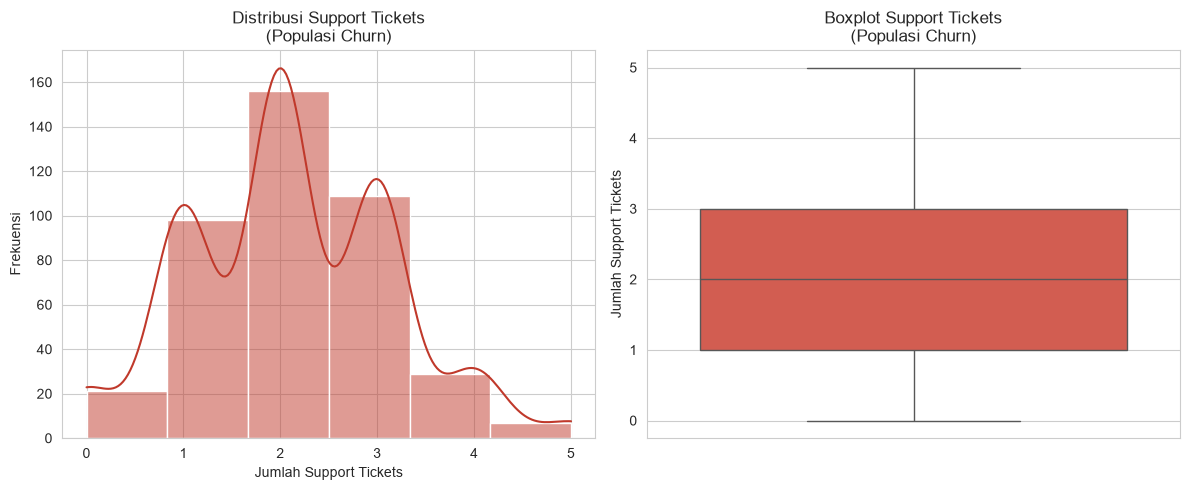

count    420.000000
mean       2.114286
std        1.052913
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: support_tickets_capped, dtype: float64

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_churn['support_tickets_capped'], bins=6, kde=True, color='#c0392b', ax=axes[0])
axes[0].set_title('Distribusi Support Tickets\n(Populasi Churn)')
axes[0].set_xlabel('Jumlah Support Tickets')
axes[0].set_ylabel('Frekuensi')

sns.boxplot(y=df_churn['support_tickets_capped'], color='#e74c3c', ax=axes[1])
axes[1].set_title('Boxplot Support Tickets\n(Populasi Churn)')
axes[1].set_ylabel('Jumlah Support Tickets')

plt.tight_layout()
plt.show()

df_churn['support_tickets_capped'].describe()

### Interpretasi

Di antara pelanggan yang churn, sebaran jumlah tiket keluhan condong ke kanan, tapi posisinya bergeser lebih tinggi dibandingkan populasi umum: median tiket pada populasi churn berada di atas median dataset keseluruhan (1 tiket). Temuan ini memperkuat dugaan bahwa akumulasi keluhan yang tidak terselesaikan adalah salah satu pemicu utama keputusan berhenti berlangganan — bukan cuma satu-dua kejadian buruk yang kebetulan terjadi.

## 7.2 Distribusi Jenis Kontrak


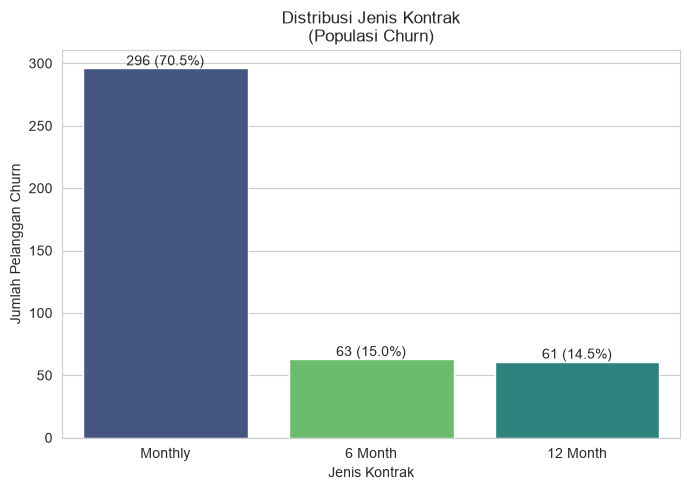

In [11]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='contract_type_label', data=df_churn, order=contract_order,
                    hue='contract_type_label', palette='viridis', legend=False)
plt.title('Distribusi Jenis Kontrak\n(Populasi Churn)')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Jumlah Pelanggan Churn')

total = len(df_churn)
for p in ax.patches:
    pct = 100 * p.get_height() / total
    ax.annotate(f'{p.get_height():.0f} ({pct:.1f}%)', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Interpretasi

Dari seluruh pelanggan yang churn, mayoritas (sekitar 70%) ternyata berasal dari kontrak **Monthly**. Ini masuk akal kalau dipikir dari sisi *barrier to exit*: kontrak bulanan tidak mengikat pelanggan secara finansial dalam jangka panjang, jadi begitu mereka merasa tidak puas, tidak ada "penalti" besar yang menahan mereka untuk tetap bertahan.

## 7.3 Distribusi Kota


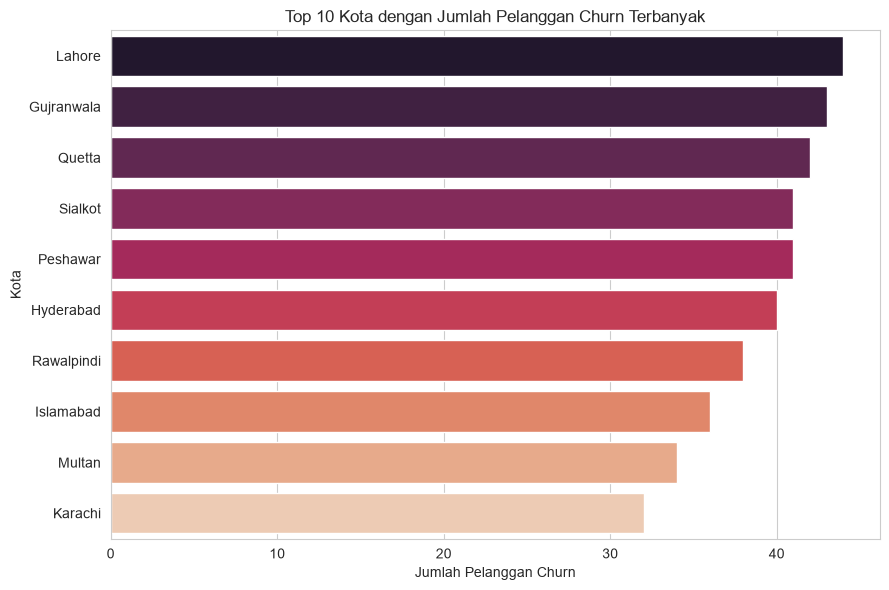

In [12]:
plt.figure(figsize=(9, 6))
city_churn_counts = df_churn['city_name'].value_counts().head(10)
ax = sns.barplot(x=city_churn_counts.values, y=city_churn_counts.index, hue=city_churn_counts.index,
                  palette='rocket', legend=False)
plt.title('Top 10 Kota dengan Jumlah Pelanggan Churn Terbanyak')
plt.xlabel('Jumlah Pelanggan Churn')
plt.ylabel('Kota')
plt.tight_layout()
plt.show()

### Interpretasi

Secara jumlah absolut, Lahore, Peshawar, dan Gujranwala berada di jajaran atas kota dengan pelanggan churn terbanyak. Ini konsisten dengan temuan *churn rate* tertinggi per kota pada laporan sebelumnya, dan cukup memperkuat dugaan bahwa ada masalah kualitas layanan yang sifatnya regional di kota-kota tersebut — bukan sekadar kebetulan statistik.

## 7.4 Distribusi Kategori Feedback

`feedback_category` adalah hasil klasifikasi berbasis kata kunci terhadap teks `customer_feedback`, yang sudah dilakukan di Notebook D, dengan pemetaan: **0 = Biaya/Tagihan, 1 = Jaringan/Sinyal, 2 = Customer Support, 3 = Positif/Puas**. Karena nilai ini nominal (bukan berjenjang), interpretasinya harus memakai label kategori, bukan mean/median — sama seperti alasan yang sudah dijelaskan di Bagian 6.


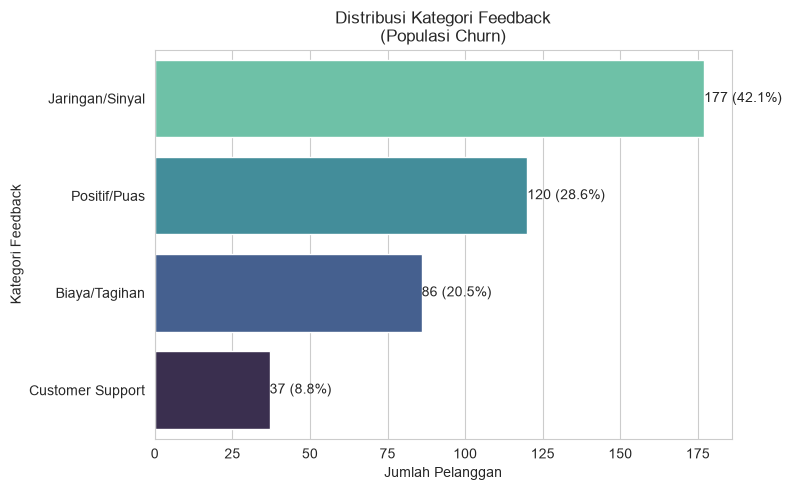

feedback_label
Jaringan/Sinyal     42.1
Positif/Puas        28.6
Biaya/Tagihan       20.5
Customer Support     8.8
Name: proportion, dtype: float64

In [13]:
feedback_label_map = {0: 'Biaya/Tagihan', 1: 'Jaringan/Sinyal', 2: 'Customer Support', 3: 'Positif/Puas'}
df_churn['feedback_label'] = df_churn['feedback_category'].map(feedback_label_map)

plt.figure(figsize=(8, 5))
order_fb = df_churn['feedback_label'].value_counts().index
ax = sns.countplot(y='feedback_label', data=df_churn, order=order_fb,
                    hue='feedback_label', palette='mako', legend=False)
plt.title('Distribusi Kategori Feedback\n(Populasi Churn)')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Kategori Feedback')

total = len(df_churn)
for p in ax.patches:
    pct = 100 * p.get_width() / total
    ax.annotate(f'{p.get_width():.0f} ({pct:.1f}%)', (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center')

plt.tight_layout()
plt.show()

df_churn['feedback_label'].value_counts(normalize=True).mul(100).round(1)

### Interpretasi

Di antara pelanggan yang churn, kategori **Jaringan/Sinyal menjadi keluhan paling dominan (sekitar 42%)**, jauh melampaui Biaya/Tagihan (sekitar 21%) dan Customer Support (sekitar 9%). Yang menarik, sekitar 29% pelanggan churn justru memberi umpan balik yang tergolong Positif/Puas — kelompok ini konsisten dengan fenomena *"happy leaver"* yang sudah diidentifikasi sebagai anomali menarik di Notebook D, yaitu pelanggan yang churn tanpa sinyal ketidakpuasan eksplisit. Temuan ini nanti jadi salah satu dasar kuantitatif untuk rekomendasi bisnis di Bagian 13.


---
# 8. Analisis Komparatif: Churn vs Tidak Churn (Scatter Plot Interaksi)

Di bagian ini aku sengaja **kembali memakai seluruh dataset** (bukan `df_churn` saja), karena tujuannya memang berbeda dari Bagian 6-7: di sini aku ingin **menguji apakah pola kualitas layanan benar-benar membedakan pelanggan churn dari yang tidak churn**. Untuk bisa membandingkan, ya kedua kelompok itu wajib hadir bersama dalam satu visualisasi — kalau cuma pakai `df_churn`, tidak ada yang bisa dibandingkan.

Draf sebelumnya memakai histogram/boxplot terpisah untuk melihat hal ini. Masalahnya di situ: histogram hanya menunjukkan sebaran **satu variabel pada satu waktu**. Ia tidak bisa menjawab pertanyaan seperti "apakah churn terjadi pada kombinasi tertentu dari dua variabel sekaligus?" — misalnya, apakah pelanggan yang churn itu biasanya punya *tiket keluhan tinggi DAN masa berlangganan pendek* secara bersamaan, atau justru dua faktor itu tidak saling berkaitan.

Nah, ini yang mendasari kenapa dosen meminta scatter plot. **Scatter plot** dengan sumbu dua variabel numerik, dan warna dibedakan berdasarkan `churn_status`, mengatasi keterbatasan itu: ia memperlihatkan **pola interaksi**, bukan sekadar sebaran satu dimensi. Kalau titik-titik churn ternyata mengelompok di area tertentu (misalnya kanan-bawah atau kiri-atas), itu langsung terlihat sebagai kombinasi kondisi yang berisiko — sesuatu yang tidak akan kelihatan kalau kedua variabel itu divisualisasikan terpisah lewat histogram.

## 8.1 Support Tickets vs Tenure (Lama Berlangganan)


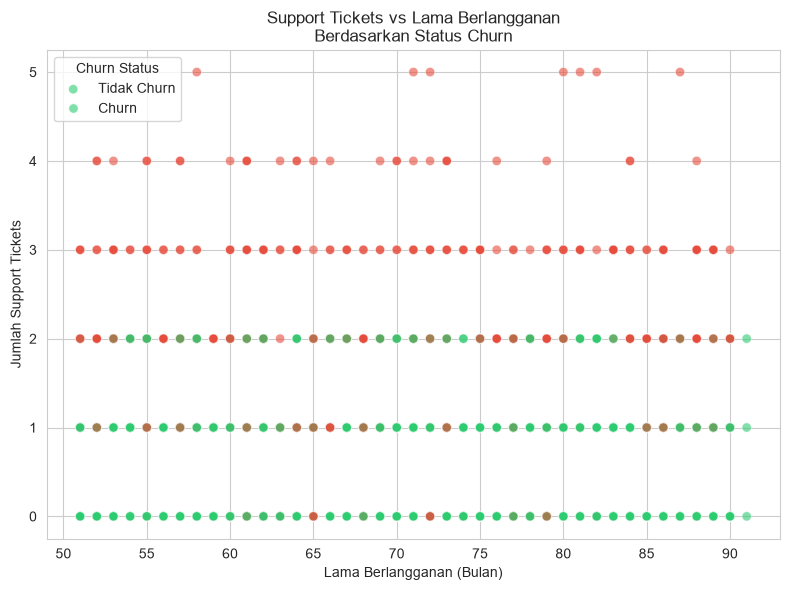

In [14]:
# Catatan teknis: palette di-set eksplisit sebagai dictionary {0: hijau, 1: merah}
# agar warna TIDAK bergantung pada urutan data yang ditampilkan, melainkan langsung
# terikat ke nilai churn_status. 0 = Tidak Churn (hijau '#2ecc71'), 1 = Churn (merah '#e74c3c').
# Urutan pada plt.legend(labels=[...]) mengikuti urutan hue yang di-sort ascending (0 lalu 1),
# sehingga label 'Tidak Churn' otomatis berpasangan dengan hijau, dan 'Churn' dengan merah.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='tenure_months', y='support_tickets_capped',
    hue='churn_status', palette={0: '#2ecc71', 1: '#e74c3c'},
    alpha=0.6, s=45
)
plt.title('Support Tickets vs Lama Berlangganan\nBerdasarkan Status Churn')
plt.xlabel('Lama Berlangganan (Bulan)')
plt.ylabel('Jumlah Support Tickets')
plt.legend(title='Churn Status', labels=['Tidak Churn', 'Churn'])
plt.tight_layout()
plt.show()


### Interpretasi

Titik-titik pelanggan churn (merah) tidak terkonsentrasi di satu rentang masa berlangganan tertentu — mereka tersebar di sepanjang sumbu `tenure_months` — tapi secara visual jelas lebih banyak menumpuk pada nilai `support_tickets` yang lebih tinggi (2 ke atas), dibandingkan pelanggan yang bertahan (hijau) yang lebih rapat di nilai 0-1 tiket. Ini menegaskan bahwa **frekuensi keluhan, bukan durasi berlangganan**, yang tampak sebagai pembeda utama churn dalam sebaran gabungan ini.

**Soal warna pada legend:** hijau memang mewakili `churn_status = 0` (Tidak Churn) dan merah mewakili `churn_status = 1` (Churn), sesuai urutan pada kotak legend "Churn Status". Ini sudah benar dan sengaja diatur eksplisit lewat parameter `palette` di kode (lihat komentar pada sel kode di atas), bukan warna acak dari default seaborn. Kalau sekilas terasa membingungkan, coba fokus ke pola datanya: titik merah (Churn) memang lebih banyak menumpuk di nilai `support_tickets` tinggi — itu konsisten dengan cerita bahwa pelanggan churn adalah yang paling sering mengeluh.

## 8.2 Support Tickets vs Tagihan Bulanan


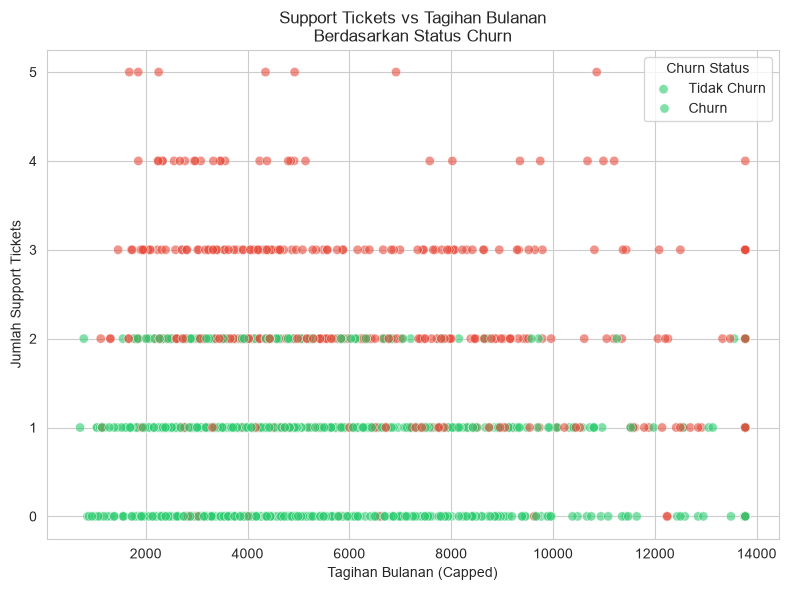

In [15]:
# Palette sama seperti scatter plot sebelumnya: 0 = Tidak Churn (hijau), 1 = Churn (merah)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df, x='monthly_bill_capped', y='support_tickets_capped',
    hue='churn_status', palette={0: '#2ecc71', 1: '#e74c3c'},
    alpha=0.6, s=45
)
plt.title('Support Tickets vs Tagihan Bulanan\nBerdasarkan Status Churn')
plt.xlabel('Tagihan Bulanan (Capped)')
plt.ylabel('Jumlah Support Tickets')
plt.legend(title='Churn Status', labels=['Tidak Churn', 'Churn'])
plt.tight_layout()
plt.show()


### Interpretasi

Pola serupa muncul di sini: pelanggan churn cenderung berada di pita `support_tickets` yang lebih tinggi di sepanjang rentang tagihan bulanan, termasuk pada pelanggan dengan tagihan tinggi yang mendekati batas *capping*. Kombinasi *tagihan tinggi + keluhan berulang* ini tampak sebagai profil risiko ganda: pelanggan yang sudah membayar mahal tapi kualitas layanannya bermasalah adalah kandidat churn yang paling rentan — masuk akal karena mereka merasa tidak mendapat nilai yang sepadan dengan biaya yang dikeluarkan.

## 8.3 Ringkasan Numerik sebagai Pembanding


In [16]:
ringkasan_banding = df.groupby('churn_status')[['support_tickets_capped', 'tenure_months', 'monthly_bill_capped']].mean().round(2)
ringkasan_banding.index = ['Tidak Churn', 'Churn']
ringkasan_banding

,support_tickets_capped,tenure_months,monthly_bill_capped
Tidak Churn,0.69,70.64,5270.75
Churn,2.11,70.52,6524.31


### Interpretasi

Ringkasan rata-rata ini menguatkan pola yang sudah terlihat di kedua scatter plot: pelanggan churn memiliki rata-rata `support_tickets` yang jauh lebih tinggi, sementara `tenure_months` antara kedua kelompok relatif tidak berbeda jauh. Dengan kata lain, ini mengonfirmasi bahwa **kualitas layanan (diwakili oleh support tickets), bukan lama berlangganan, adalah sinyal churn yang lebih kuat** — dan ini sejalan dengan fokus utama seluruh analisis Bagian B.


---
# 9. Analisis Multivariat pada Populasi Churn

Kembali menggunakan `df_churn`. Kalau Bagian 7 tadi melihat variabel satu per satu, di sini aku pakai tabel pivot untuk melihat pola gabungan lebih dari satu variabel dalam populasi churn — pola yang tidak akan kelihatan kalau dilihat sendiri-sendiri.

## 9.1 Sebaran Jenis Kontrak Berdasarkan Kota (Populasi Churn)


In [17]:
pivot_kontrak_kota = pd.crosstab(df_churn['city_name'], df_churn['contract_type_label'])
pivot_kontrak_kota = pivot_kontrak_kota[contract_order]
pivot_kontrak_kota['Total'] = pivot_kontrak_kota.sum(axis=1)
pivot_kontrak_kota.sort_values('Total', ascending=False)

contract_type_label,Monthly,6 Month,12 Month,Total
city_name,,,,
Lahore,35,6,3,44
Gujranwala,31,6,6,43
Quetta,27,9,6,42
Peshawar,34,4,3,41
Sialkot,27,8,6,41
Hyderabad,28,1,11,40
Rawalpindi,22,10,6,38
Islamabad,26,8,2,36
Multan,20,6,8,34


### Interpretasi

Tabel ini menunjukkan bahwa dominasi kontrak Monthly pada populasi churn (yang sudah terlihat di Bagian 7.2) ternyata konsisten di hampir seluruh kota, bukan cuma terkonsentrasi di satu wilayah tertentu. Ini mengindikasikan bahwa masalah kontrak bulanan sifatnya sistemik — berlaku merata di berbagai lokasi, bukan sekadar isu lokal di satu-dua kota saja.

## 9.2 Rata-rata Support Tickets per Jenis Kontrak (Populasi Churn)


In [18]:
pivot_tiket_kontrak = df_churn.pivot_table(values='support_tickets_capped', index='contract_type_label',
                                            aggfunc='mean').reindex(contract_order)
pivot_tiket_kontrak.round(2)

,support_tickets_capped
contract_type_label,
Monthly,1.81
6 Month,2.97
12 Month,2.72


### Interpretasi

Bahkan di antara pelanggan yang sama-sama sudah churn, pelanggan dengan kontrak 6-Month tercatat memiliki rata-rata tiket keluhan tertinggi. Ini cukup menarik, karena mengindikasikan bahwa pelanggan kontrak menengah cenderung "berjuang" lebih dulu — mengajukan lebih banyak keluhan — sebelum akhirnya memutuskan berhenti, dibandingkan pelanggan Monthly yang tampaknya lebih cepat memutuskan pergi begitu merasa tidak puas.

## 9.3 Kategori Feedback per Jenis Kontrak (Populasi Churn)


In [19]:
pivot_feedback_kontrak = pd.crosstab(df_churn['contract_type_label'], df_churn['feedback_label'], normalize='index').mul(100).round(1)
pivot_feedback_kontrak = pivot_feedback_kontrak.reindex(contract_order)
pivot_feedback_kontrak

feedback_label,Biaya/Tagihan,Customer Support,Jaringan/Sinyal,Positif/Puas
contract_type_label,,,,
Monthly,20.3,9.5,41.6,28.7
6 Month,19.0,7.9,44.4,28.6
12 Month,23.0,6.6,42.6,27.9


### Interpretasi

Persentase keluhan Jaringan/Sinyal tetap menjadi kategori dominan di seluruh jenis kontrak pada populasi churn. Artinya, masalah ini bukan spesifik pada satu segmen kontrak tertentu, melainkan pain point lintas segmen yang perlu ditangani secara menyeluruh — bukan solusi yang disesuaikan per jenis kontrak.


---
# 10. Validasi Outlier pada Populasi Churn

Sebelum lanjut ke korelasi, aku ingin memastikan satu hal: apakah proses *capping* pada tahap preprocessing (Notebook D) masih efektif membatasi nilai ekstrem, bahkan setelah data difilter khusus untuk populasi churn saja? Ini penting supaya bagian korelasi berikutnya tidak terdistorsi oleh outlier residual.


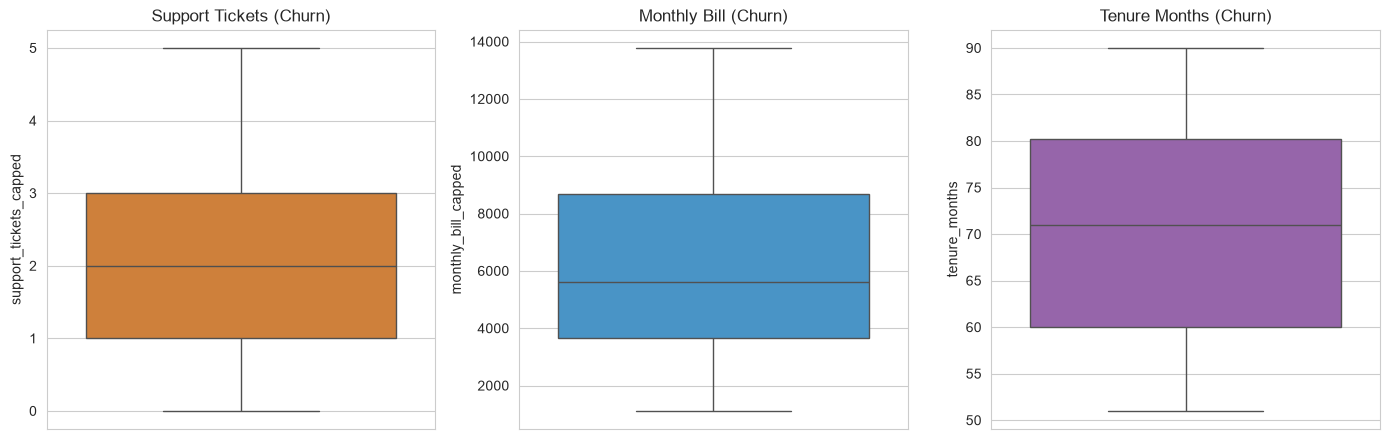

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sns.boxplot(y=df_churn['support_tickets_capped'], ax=axes[0], color='#e67e22')
axes[0].set_title('Support Tickets (Churn)')

sns.boxplot(y=df_churn['monthly_bill_capped'], ax=axes[1], color='#3498db')
axes[1].set_title('Monthly Bill (Churn)')

sns.boxplot(y=df_churn['tenure_months'], ax=axes[2], color='#9b59b6')
axes[2].set_title('Tenure Months (Churn)')

plt.tight_layout()
plt.show()

### Interpretasi

Nilai ekstrem pada ketiga variabel tetap berada dalam batas yang wajar setelah *capping*, meskipun sudah difilter khusus ke populasi churn. Artinya, analisis pada populasi churn ini tidak terdistorsi oleh outlier residual — aman untuk dilanjutkan ke analisis korelasi.


---
# 11. Korelasi Antar Variabel Kualitas Layanan

Berbeda dari Notebook D yang menampilkan matriks korelasi untuk **seluruh 42 kolom** (tujuannya untuk cek multikolinearitas sebelum pemodelan), di sini aku sengaja mempersempit matriks korelasi hanya pada variabel yang relevan dengan tugas Orang B. Alasannya sederhana: kalau semua 42 kolom ditampilkan lagi, hasilnya jadi terlalu ramai dan tidak fokus untuk kebutuhan analisis kualitas layanan yang jadi topik notebook ini.


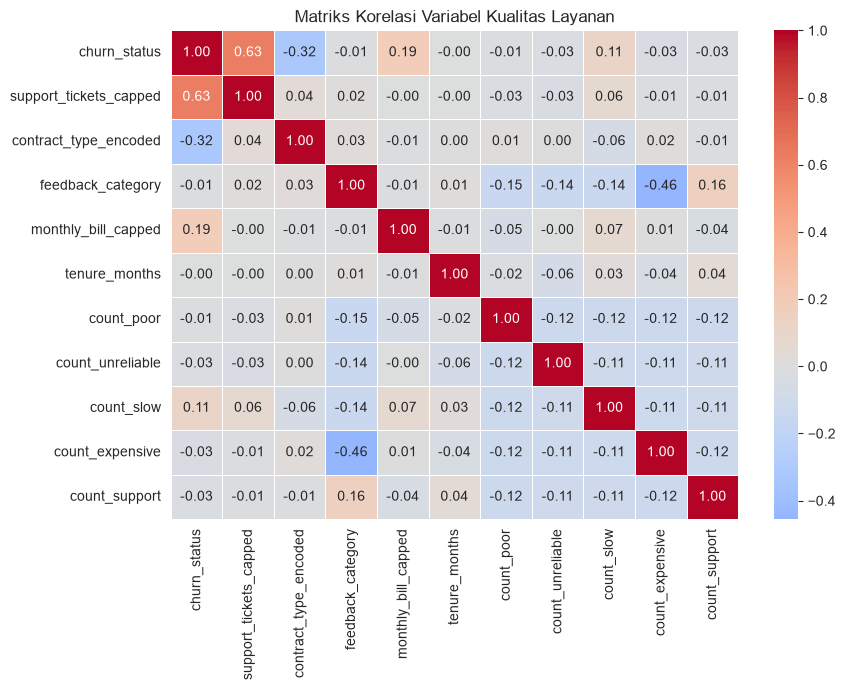

In [21]:
fokus_kolom = ['churn_status', 'support_tickets_capped', 'contract_type_encoded',
               'feedback_category', 'monthly_bill_capped', 'tenure_months',
               'count_poor', 'count_unreliable', 'count_slow', 'count_expensive', 'count_support']

corr_fokus = df[fokus_kolom].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_fokus, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=.5)
plt.title('Matriks Korelasi Variabel Kualitas Layanan')
plt.tight_layout()
plt.show()

### Interpretasi

`support_tickets_capped` menunjukkan korelasi positif paling kuat terhadap `churn_status` di antara variabel yang diuji, sementara `contract_type_encoded` menunjukkan korelasi negatif (kontrak lebih panjang → churn lebih rendah). Korelasi antar variabel kata kunci (`count_poor`, `count_unreliable`, `count_slow`) relatif lemah satu sama lain — ini wajar, karena ketiganya merepresentasikan kata kunci berbeda dari teks umpan balik yang tidak selalu muncul bersamaan dalam satu kalimat.

**Catatan kualitas data:** saat eksplorasi awal aku menemukan bahwa kolom `count_billing`, `count_happy`, dan `count_satisfied` bernilai nol di seluruh baris data — kemungkinan akibat isu pencocokan kata kunci pada tahap *Count Vectorizer* di Notebook D. Ketiga kolom ini aku keluarkan dari analisis kuantitatif dan digantikan oleh `feedback_category` (yang tetap valid) sebagai sumber informasi kategori Biaya/Tagihan dan sentimen positif.


---
# 12. Insight Bisnis

Setelah semua analisis di atas, berikut aku rangkum temuan utamanya:

1. **Frekuensi keluhan adalah sinyal churn yang lebih kuat daripada lama berlangganan.** Baik pada perbandingan churn vs tidak churn (Bagian 8) maupun pada profil internal populasi churn (Bagian 6-7), `support_tickets` konsisten muncul sebagai variabel pembeda utama.
2. **Kontrak Monthly mendominasi populasi churn** (~70%), dan pola ini konsisten di hampir seluruh kota — menunjukkan masalah struktural terkait rendahnya *barrier to exit*, bukan sekadar kebetulan geografis.
3. **Masalah Jaringan/Sinyal adalah kategori keluhan paling dominan pada pelanggan churn** (~42%), jauh di atas Biaya/Tagihan (~21%) dan Customer Support (~9%), berdasarkan kategori umpan balik tekstual yang sudah diklasifikasikan pada Notebook D.
4. **Terdapat kelompok *"happy leaver"*** (~29% dari populasi churn) yang memberi umpan balik positif namun tetap churn — mengindikasikan bahwa sebagian churn didorong faktor di luar layanan teknis (misalnya harga kompetitor atau perubahan kebutuhan), bukan murni ketidakpuasan layanan.
5. **Lahore, Peshawar, dan Gujranwala** adalah kota dengan jumlah pelanggan churn absolut tertinggi, konsisten dengan temuan *churn rate* per kota pada laporan sebelumnya.


---
# 13. Rekomendasi Bisnis Berbasis Data Feedback Pelanggan

Ini bagian yang paling banyak berubah dari sisi filosofi penyusunannya. Sesuai catatan dosen, rekomendasi di bawah ini disusun **berdasarkan kuantifikasi kategori dan kata kunci feedback pelanggan churn** (merujuk balik ke Bagian 7.4 dan 11), bukan dari asumsi umum atau opini pribadi soal apa yang "biasanya" jadi masalah di industri telekomunikasi.

> 📝 **Catatan revisi:** di draf lama, rekomendasi ditulis tanpa tabel pendukung dan tanpa merujuk balik ke angka spesifik dari hasil analisis. Di draf ini, setiap poin rekomendasi mencantumkan persentase pendukungnya secara eksplisit, dan dibuka dengan tabel kuantifikasi di bawah ini.


In [22]:
kontribusi_pain_point = pd.DataFrame({
    'Kategori': ['Jaringan/Sinyal', 'Biaya/Tagihan', 'Customer Support', 'Positif/Puas'],
    'Persentase Pelanggan Churn (%)': [
        (df_churn['feedback_category'] == 1).mean() * 100,
        (df_churn['feedback_category'] == 0).mean() * 100,
        (df_churn['feedback_category'] == 2).mean() * 100,
        (df_churn['feedback_category'] == 3).mean() * 100,
    ]
}).round(1).sort_values('Persentase Pelanggan Churn (%)', ascending=False)

kontribusi_pain_point

,Kategori,Persentase Pelanggan Churn (%)
0,Jaringan/Sinyal,42.1
3,Positif/Puas,28.6
1,Biaya/Tagihan,20.5
2,Customer Support,8.8


### Interpretasi Kuantitatif

Tabel di atas jadi dasar penentuan prioritas rekomendasi: hampir setengah dari pelanggan churn menyampaikan keluhan terkait jaringan/sinyal. Artinya, perbaikan **infrastruktur teknis** semestinya jadi prioritas tertinggi — bukan sekadar mengandalkan program diskon harga, yang belum tentu menyentuh akar masalahnya.

### Rekomendasi

1. **Prioritas Utama — Audit dan Perbaikan Infrastruktur Jaringan (didukung ~42% feedback churn):** Fokuskan investasi teknis pada penguatan sinyal dan stabilitas koneksi, terutama di kota dengan volume churn tertinggi (Lahore, Peshawar, Gujranwala), karena kategori Jaringan/Sinyal adalah pain point paling banyak disebut oleh pelanggan yang sudah pergi.
2. **Early Warning System Berbasis Tiket Keluhan:** Karena `support_tickets` terbukti menjadi pembeda churn paling konsisten (Bagian 8 dan 11), pelanggan dengan 2 tiket keluhan atau lebih dalam satu periode tagihan sebaiknya otomatis ditandai sebagai *at-risk* untuk intervensi retensi proaktif.
3. **Program Migrasi Kontrak Monthly:** Karena ~70% populasi churn berasal dari kontrak Monthly dan pola ini merata di seluruh kota (Bagian 9.1), insentif migrasi ke kontrak jangka panjang sebaiknya diterapkan secara nasional, bukan hanya di kota tertentu.
4. **Program Retensi Khusus untuk Kelompok "Happy Leaver" (~29% populasi churn):** Karena kelompok ini churn tanpa keluhan layanan, penyebabnya kemungkinan besar berasal dari faktor eksternal (harga kompetitor, kebutuhan berubah). Survei keluar (*exit survey*) singkat perlu ditambahkan pada proses pembatalan layanan untuk mengonfirmasi alasan sebenarnya, karena data feedback saat ini tidak bisa menjelaskan kelompok ini.
5. **Perbaikan Kualitas Data Feedback:** Karena ditemukan bahwa kolom kata kunci `count_billing`, `count_happy`, dan `count_satisfied` tidak berfungsi (bernilai nol seluruhnya), tim data disarankan meninjau ulang proses *Count Vectorizer* pada Notebook D sebelum data ini dipakai untuk analisis kuantitatif lain di luar `feedback_category`.


---
# 14. Kesimpulan

Bagian ini murni membahas **apa yang dihasilkan** dari seluruh analisis di notebook ini, dan menjawab langsung rumusan masalah serta tujuan yang disebutkan di Bagian 1.1. Untuk daftar perbaikan teknis dari draf sebelumnya, silakan lihat kembali Bagian 0 (Ringkasan Revisi) di awal notebook.

**Menjawab rumusan masalah — "Bagaimana kualitas layanan dan pain points pelanggan berkontribusi terhadap keputusan churn?":**

1. **Frekuensi keluhan (`support_tickets`) adalah kontributor paling konsisten terhadap churn**, baik dilihat dari perbandingan churn vs tidak churn (Bagian 8) maupun dari profil internal populasi churn (Bagian 6-7, 11). Pelanggan yang churn secara khas memiliki jumlah tiket keluhan yang jauh lebih tinggi dibanding pelanggan yang bertahan, sementara lama berlangganan (`tenure_months`) tidak menunjukkan pola pembeda yang jelas.
2. **Jenis kontrak turut berkontribusi lewat mekanisme *barrier to exit*.** Kontrak Monthly mendominasi populasi churn (~70%) secara merata di hampir seluruh kota, menunjukkan bahwa rendahnya komitmen finansial mempermudah pelanggan untuk pergi begitu mereka tidak puas.
3. **Pain point yang paling banyak disuarakan pelanggan churn adalah masalah Jaringan/Sinyal (~42%)**, jauh di atas Biaya/Tagihan (~21%) dan Customer Support (~9%) — sehingga secara kualitas layanan, aspek teknis infrastruktur adalah kontributor terbesar terhadap ketidakpuasan yang berujung churn.
4. **Tidak semua churn bisa dijelaskan oleh ketidakpuasan layanan.** Ditemukan kelompok *"happy leaver"* (~29% dari populasi churn) yang memberi feedback positif namun tetap berhenti berlangganan — mengindikasikan bahwa faktor di luar kualitas layanan (misalnya harga kompetitor atau perubahan kebutuhan) juga berperan, dan ini jadi keterbatasan yang perlu diakui secara jujur dari analisis berbasis feedback saja.

**Menjawab tujuan — "Menganalisis hubungan kualitas layanan dan pain points pelanggan terhadap churn":**

Secara keseluruhan, notebook ini menunjukkan bahwa kualitas layanan — terutama frekuensi keluhan dan masalah jaringan/sinyal — memiliki hubungan yang jelas dan terukur dengan keputusan churn, sementara jenis kontrak memperkuat hubungan itu lewat mekanisme *barrier to exit*. Temuan-temuan pada notebook ini secara langsung mendukung dan memperkaya bagian Rekomendasi Bisnis pada laporan akhir kelompok (Bab 4.7.2), khususnya dengan menambahkan dasar kuantitatif dari sisi feedback tekstual yang sebelumnya belum dimanfaatkan.

**Keterbatasan dan catatan untuk pengembangan lanjutan:** kelompok *"happy leaver"* yang disebut di atas tidak bisa dijelaskan tuntas oleh data feedback yang tersedia saat ini. Ini menandakan perlunya sumber data tambahan (misalnya *exit survey*) untuk melengkapi analisis pain point pada iterasi berikutnya, supaya rekomendasi retensi bisa menjangkau juga kelompok yang churn bukan karena masalah teknis.
